In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Input files doesn't have column names

In [2]:
dependent_var= ['RUL']
index_columns_names= ["UnitNumber","Cycle"]

In [3]:
Opset=[]
Opset.append("OpSet1")
Opset.append("OpSet2")
Opset.append("OpSet3")

In [4]:
#assigning column names
sensor_columns_names=[]
for i in range(1,22):
    s=str(i)
    sensor_columns_names.append("SensorMeasure"+s)
input_column_names = index_columns_names + Opset + sensor_columns_names

Importing train dataset and calculating remaining useful life

In [5]:
file="train_FD001.txt"
df_train=pd.read_csv(file,sep=r"\s+",names=input_column_names)

In [6]:
g_data= df_train.groupby('UnitNumber')
c_data = g_data['Cycle']
max_cycle= c_data.max()
rul = pd.DataFrame(max_cycle).reset_index()

In [7]:

rul.columns = ['UnitNumber', 'max']
m=['UnitNumber']
df_train = df_train.merge(rul, on=m, how='left')
df_train['RUL']= df_train['max'] - df_train['Cycle']
df_train.drop('max',axis=1,inplace=True)

df_train.head()

,UnitNumber,Cycle,OpSet1,OpSet2,OpSet3,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,...,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


Importing Test dataset

In [8]:
df_test = pd.read_csv('test_FD001.txt', sep=r"\s+", names=input_column_names)
df_test.head()
df_test.to_csv("test_data.csv", index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'test_FD001.txt'

Importing True RUL of engines of Test data

In [ ]:
y_true= pd.read_csv('RUL_FD001.txt',sep=r"\s+",names=["RUL"])
y_true["UnitNumber"]= y_true.index
y_true.head()

,RUL,UnitNumber
0,112,0
1,98,1
2,69,2
3,82,3
4,91,4


Data Analysis

In [ ]:
df_train.shape

(20631, 27)

Dataframe has total 20631 unique observations and 26 features.

In [ ]:
df_train.isnull().sum()

UnitNumber         0
Cycle              0
OpSet1             0
OpSet2             0
OpSet3             0
SensorMeasure1     0
SensorMeasure2     0
SensorMeasure3     0
SensorMeasure4     0
SensorMeasure5     0
SensorMeasure6     0
SensorMeasure7     0
SensorMeasure8     0
SensorMeasure9     0
SensorMeasure10    0
SensorMeasure11    0
SensorMeasure12    0
SensorMeasure13    0
SensorMeasure14    0
SensorMeasure15    0
SensorMeasure16    0
SensorMeasure17    0
SensorMeasure18    0
SensorMeasure19    0
SensorMeasure20    0
SensorMeasure21    0
RUL                0
dtype: int64

Unit

In [ ]:
df_train.UnitNumber.unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

Cycle

In [ ]:
df_train.Cycle.unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

Dataframe has observations for total 100 different units and 362 cycles data present .

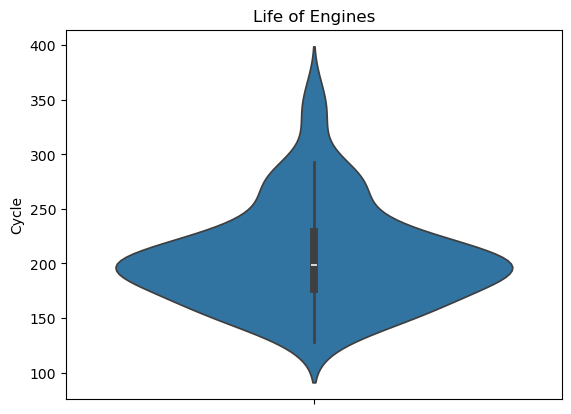

In [ ]:
temp_df = df_train[["UnitNumber","Cycle"]].groupby("UnitNumber").max()
sns.violinplot(temp_df.Cycle)
plt.title("Life of Engines")
plt.show()

The plot helps to understand the variability in engine degradation behavior. Since engine lifespans are not same or uniform, the model needs to learn different degradation patterns rather than taking a assumption of fixed failure point.

As the plot shows, average life of an Engine is around 200 cycles but some engines lived 360 cycles as well.

Engines having maximum life

In [ ]:
s= df_train[["UnitNumber", "Cycle"]]
m = s.groupby("UnitNumber").max()
sorted = m.sort_values(by="Cycle", ascending=False)
top_5_units = sorted.head(5)
print(top_5_units)

            Cycle
UnitNumber       
69            362
92            341
96            336
67            313
83            293


Engines having minimum life

In [ ]:
min_life = sorted.tail(5)
min_life

,Cycle
UnitNumber,
58,147
70,137
57,137
91,135
39,128


In our data set, each engine operates under slightly different conditions, characterized by three dimensions which change over time (e.g. altitude or external air pressure). The figure below shows the values of these operational conditions over time for the same example engine.

Operational Setting
Are engines working under the same conditions or different conditions?

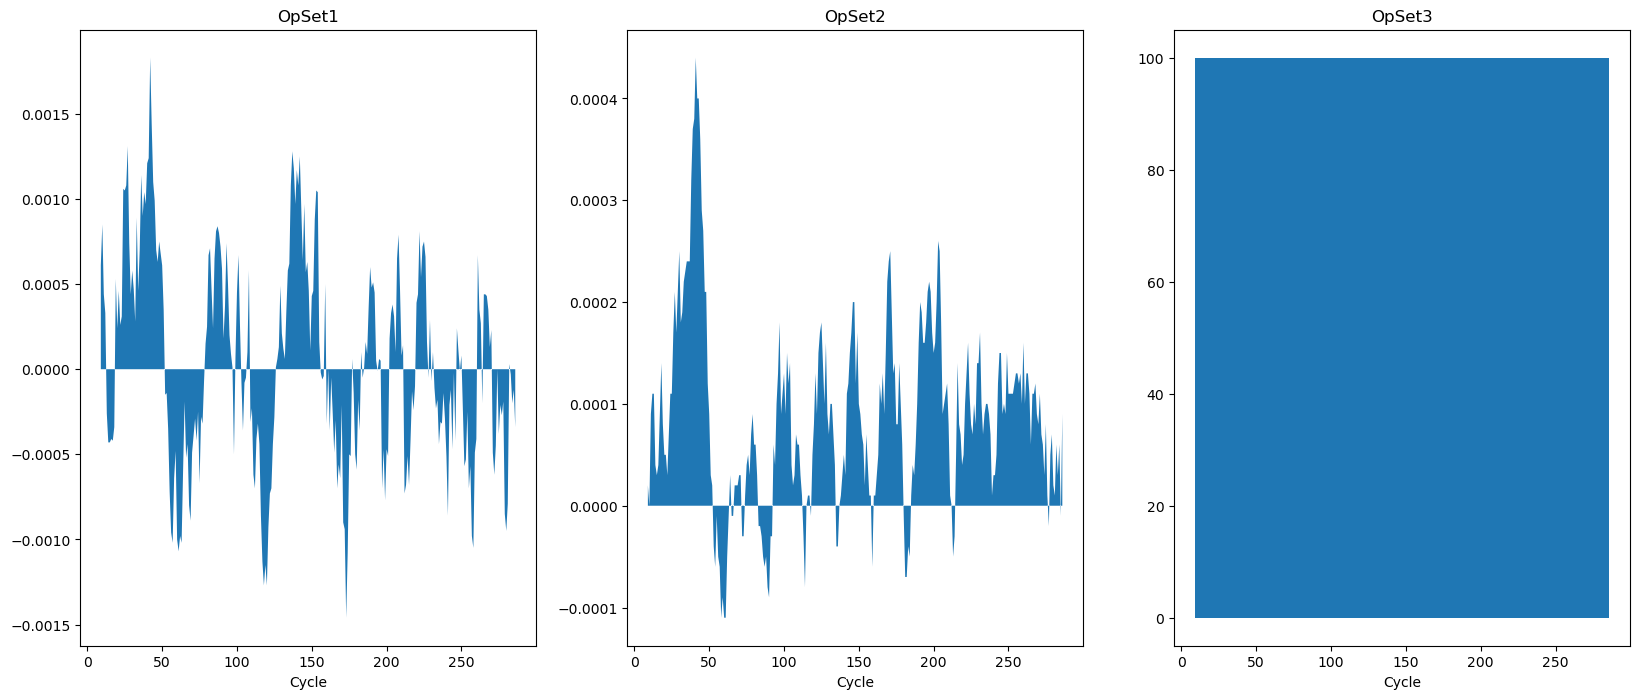

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
df_u1 = df_train[df_train['UnitNumber'] == 2]
df_u1=df_u1.reset_index(drop=True)

for i in range(3):
    data = df_u1['OpSet' + str(i+1)].rolling(window=10).mean()

    ax[i].fill_between(range(len(data)), data)
    ax[i].set_title('OpSet' + str(i+1))
    ax[i].set_xlabel("Cycle")

plt.show()

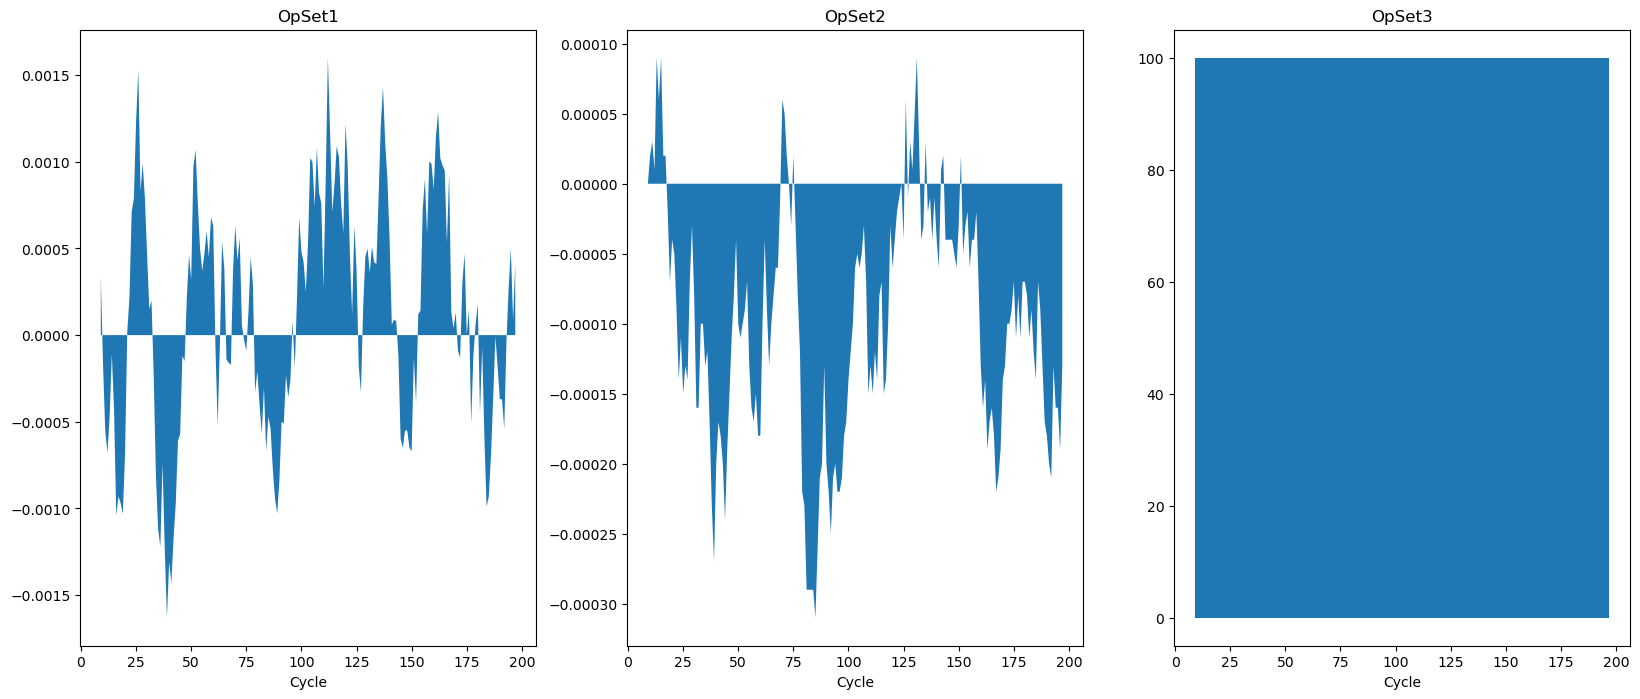

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 8))

df_u1 = df_train[df_train['UnitNumber'] == 50].reset_index(drop=True)

for i in range(3):
    data = df_u1['OpSet' + str(i+1)].rolling(window=10).mean()

    ax[i].fill_between(range(len(data)), data)
    ax[i].set_title('OpSet' + str(i+1))
    ax[i].set_xlabel("Cycle")

plt.show()

From the visualization, OpSet3 is constant across all cycles, indicating zero variance, so it does not contribute to prediction and can be removed. OpSet1 and OpSet2 show minor fluctuations but no clear degradation trend, suggesting limited usefulness compared to sensor features

### OpSet1

Visualizing Operating Setting 1 of units 1 to 15.

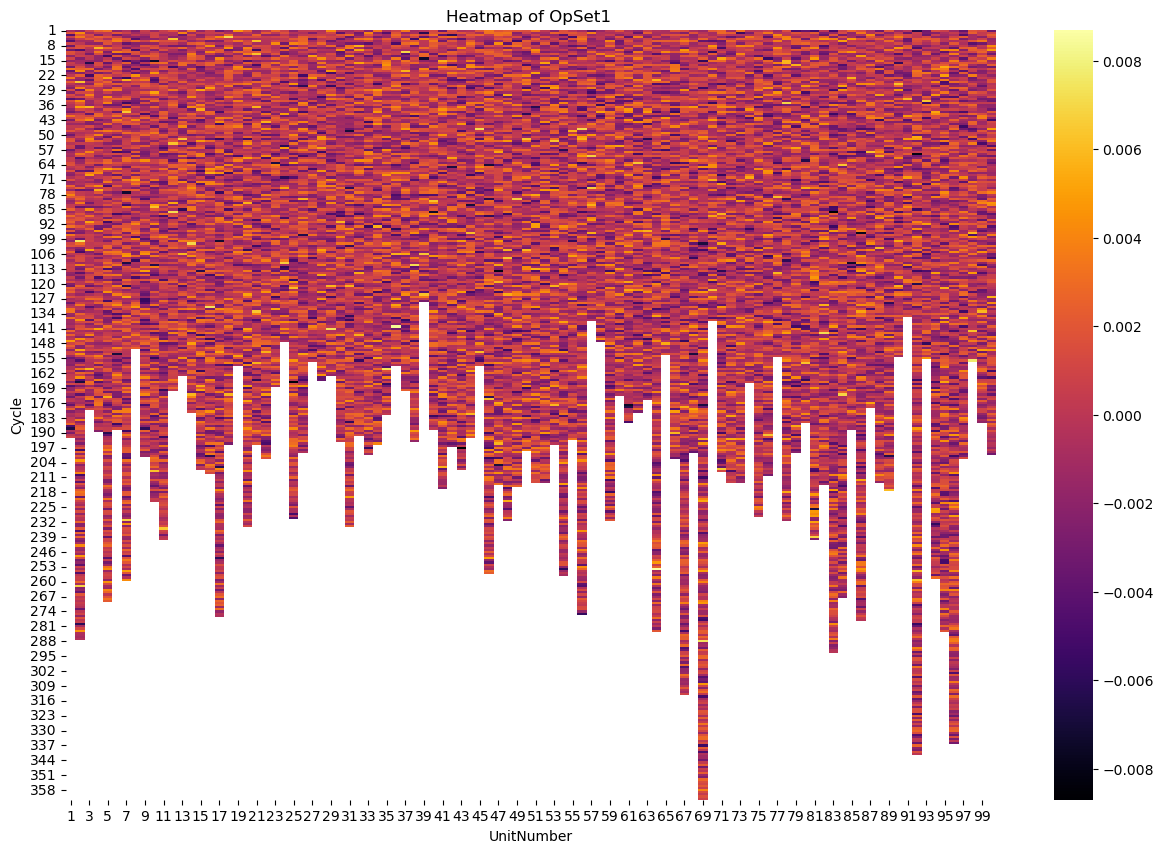

In [ ]:
opset_1= df_train.pivot(values='OpSet1', columns='UnitNumber',index='Cycle')
plt.figure(figsize=(15, 10))
sns.heatmap(opset_1, cmap='inferno')
plt.title("Heatmap of OpSet1 ")
plt.ylabel("Cycle")
plt.xlabel("UnitNumber")
plt.show()

### OpSet2

Visualizing Operating Setting 2 of units 1 to 15.

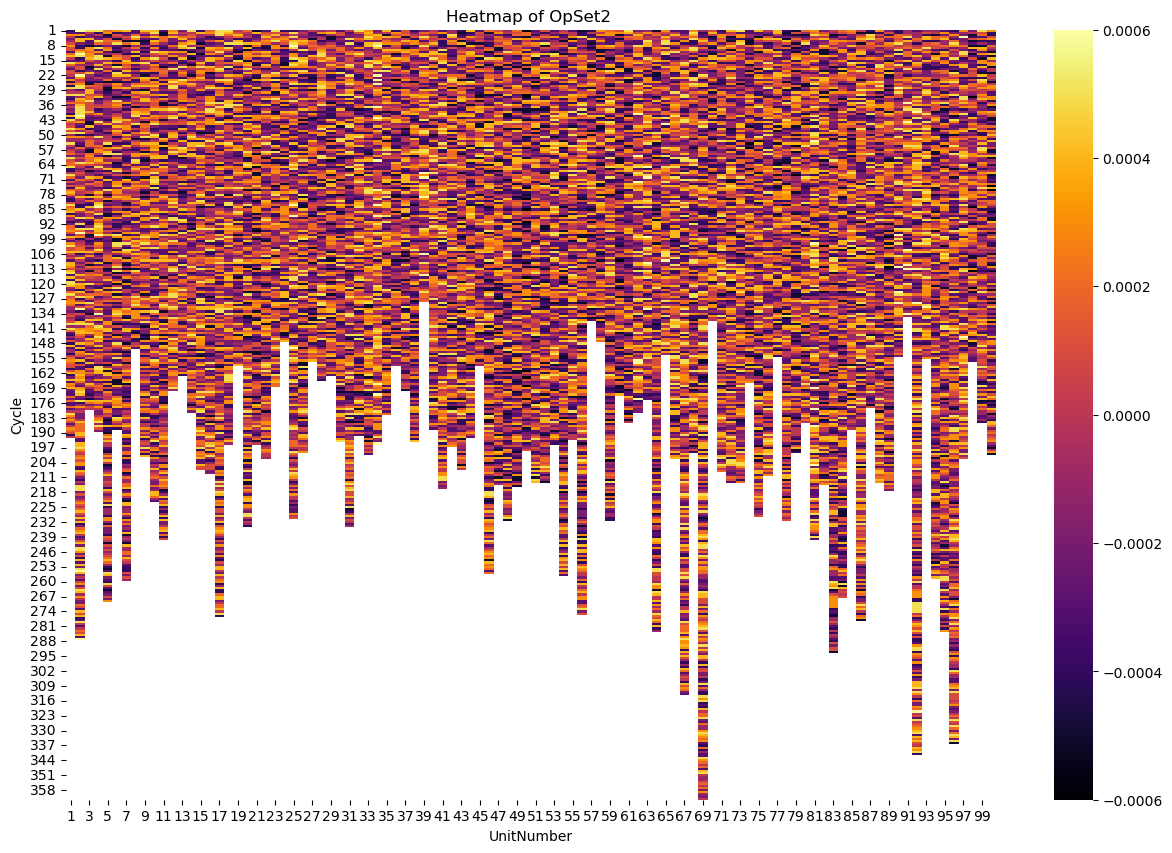

In [ ]:
opset_2= df_train.pivot(values='OpSet2', columns='UnitNumber',index='Cycle')
plt.figure(figsize=(15, 10))
sns.heatmap(opset_2, cmap='inferno')
plt.title("Heatmap of OpSet2 ")
plt.ylabel("Cycle")
plt.xlabel("UnitNumber")
plt.show()

### OpSet3

Visualizing Operating Setting 3 of units 1 to 15.

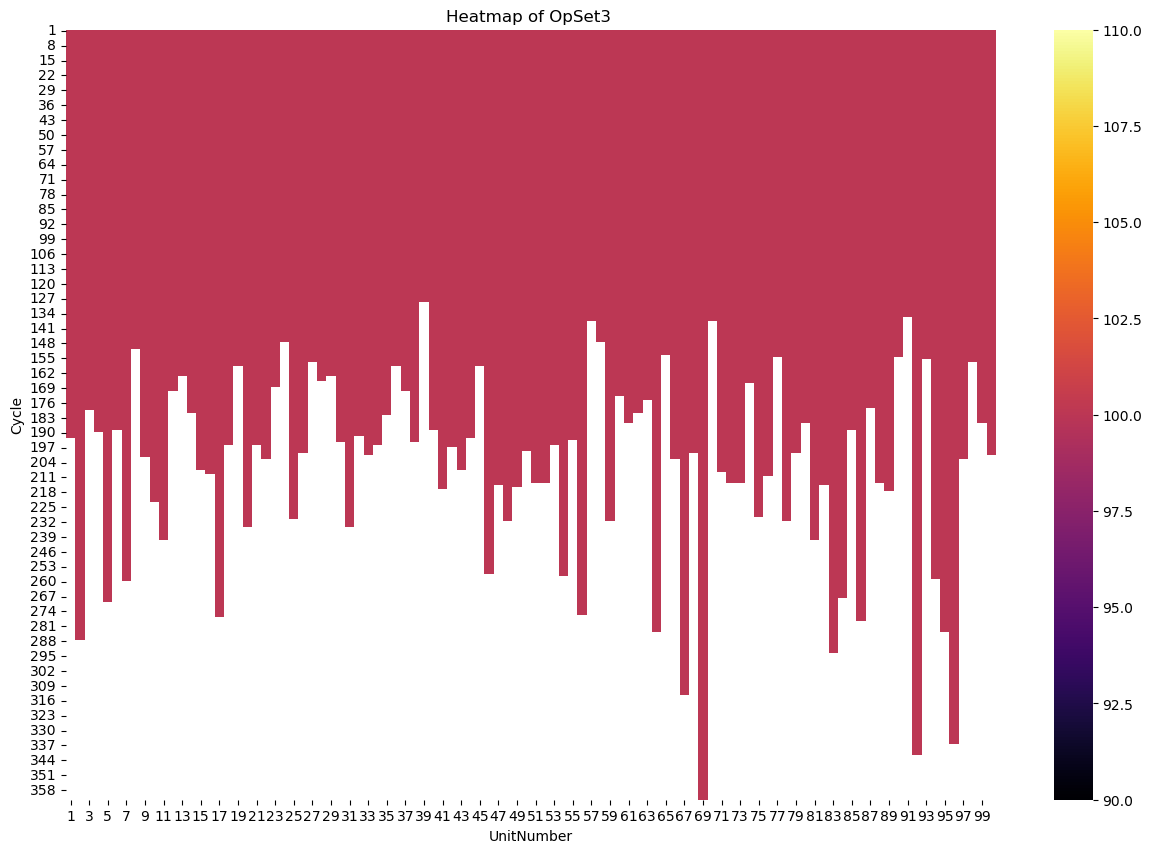

In [ ]:
opset_3= df_train.pivot(index='Cycle', columns='UnitNumber', values='OpSet3')
plt.figure(figsize=(15, 10))
sns.heatmap(opset_3, cmap='inferno')
plt.title("Heatmap of OpSet3 ")
plt.xlabel("UnitNumber")
plt.ylabel("Cycle")
plt.show()

In [ ]:
temp_df = df_train.groupby('UnitNumber')['OpSet3'].std()
temp_df.sort_values(ascending=False).head()

UnitNumber
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
Name: OpSet3, dtype: float64

In [ ]:
temp_df = df_train.groupby('UnitNumber')['OpSet3'].mean()
temp_df.sort_values(ascending=False).head()

UnitNumber
1    100.0
2    100.0
3    100.0
4    100.0
5    100.0
Name: OpSet3, dtype: float64

Operational Settings 1 and 2 do not show clear signal of failure but they might be important. Operational Setting 3 remains same throughout engine's life. Also, its value is same (i.e. 100) among all engines. Therefore, we can drop this feature.

## Sensor Measurements

In [ ]:
sensor_cols = []
for i in range(1, 22):
    column_name = "SensorMeasure" + str(i)
    sensor_cols.append(column_name)
print(sensor_cols)

['SensorMeasure1', 'SensorMeasure2', 'SensorMeasure3', 'SensorMeasure4', 'SensorMeasure5', 'SensorMeasure6', 'SensorMeasure7', 'SensorMeasure8', 'SensorMeasure9', 'SensorMeasure10', 'SensorMeasure11', 'SensorMeasure12', 'SensorMeasure13', 'SensorMeasure14', 'SensorMeasure15', 'SensorMeasure16', 'SensorMeasure17', 'SensorMeasure18', 'SensorMeasure19', 'SensorMeasure20', 'SensorMeasure21']


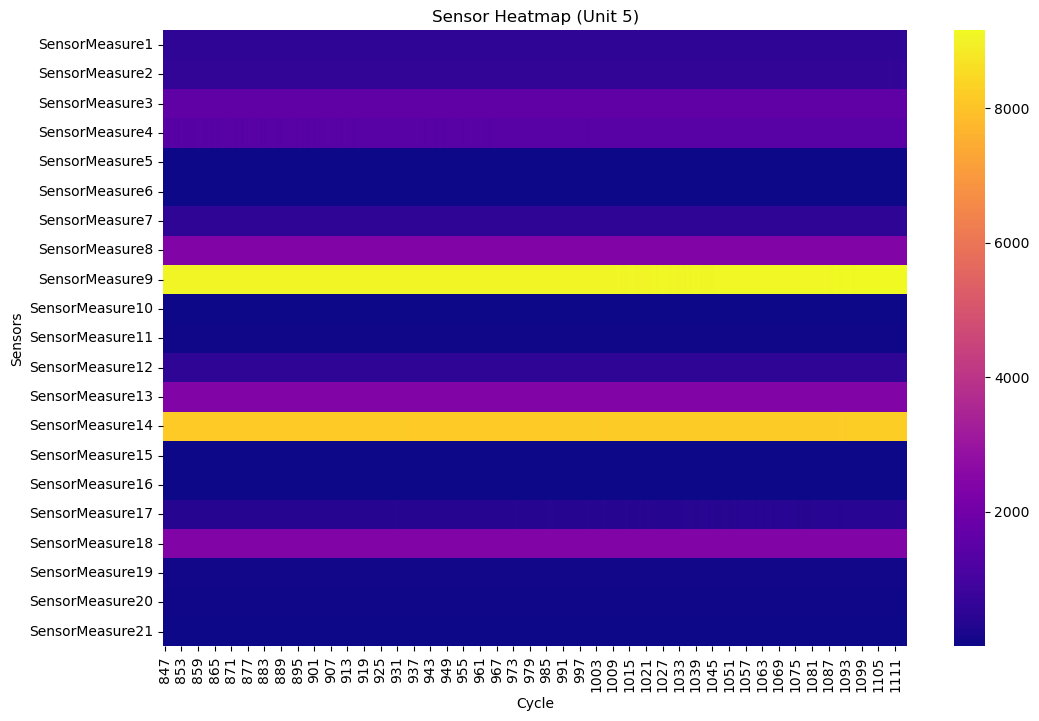

In [ ]:
u1 = df_train[df_train['UnitNumber'] == 5]
plt.figure(figsize=(12, 8))
sns.heatmap(u1[sensor_cols].T, cmap='plasma')
plt.title("Sensor Heatmap (Unit 5)")
plt.ylabel("Sensors")
plt.xlabel("Cycle")
plt.show()

Observations from Heatmap:
Plain Sensors (No Color Change)

Example: SensorMeasure 5, 6, 10, 15, 20, 21.
meaning: These sensors show almost constant values. They do not show a pattern of wear or damage over time, which makes them unhelpful for predicting when a machine might fail.

Sensors with Slight Variation

Example: SensorMeasure 1, 2, 3, 4, 7, 11, 12, 17.

meaning: These show small changes. They might contain a weak signal, but they are not showing a clear or strong trend.

Sensors with High Values (Bright Lines)

Example: SensorMeasure 9, 14, 18.

meaning: While these sensors shows as bright colors, they still do not change much over time. A high value that stays the same is just as uninformative as a low value that stays the same.

The Most Important Insight
The heatmap shows almost no horizontal change in color as time passes. This means the sensors are not showing a clear trend of getting worse or wearing down for this specific unit.


Some sensors remain same throughout engine's life. Checking their values across different engines.

In [ ]:
temp= df_train.groupby('UnitNumber').std()
temp.head()

,Cycle,OpSet1,OpSet2,OpSet3,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,SensorMeasure6,...,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21,RUL
UnitNumber,,,,,,,,,,,,,,,,,,,,,
1,55.569776,0.001953,0.000282,0.0,0.0,0.486795,5.759776,8.565610,0.0,0.000000,...,0.076960,5.563129,0.034125,0.0,1.475661,0.0,0.0,0.166998,0.105101,55.569776
2,82.993976,0.002320,0.000298,0.0,0.0,0.560214,6.596730,9.737248,0.0,0.002491,...,0.063861,8.683012,0.041128,0.0,1.647280,0.0,0.0,0.199332,0.114796,82.993976
3,51.816986,0.002145,0.000290,0.0,0.0,0.474190,6.386222,8.610126,0.0,0.001482,...,0.041219,29.439715,0.036620,0.0,1.570773,0.0,0.0,0.166112,0.104734,51.816986
4,54.703748,0.002033,0.000286,0.0,0.0,0.441446,6.109152,7.737463,0.0,0.000727,...,0.034819,30.691780,0.031947,0.0,1.602848,0.0,0.0,0.159302,0.093804,54.703748
5,77.797815,0.002119,0.000279,0.0,0.0,0.551542,7.060648,9.782341,0.0,0.002503,...,0.056445,16.480153,0.038658,0.0,1.740057,0.0,0.0,0.187133,0.112705,77.797815


In [ ]:
temp_df.sum(axis = 0) == 0

np.False_

#### Sensor Measure 1

In [ ]:
temp_df = df_train.groupby('UnitNumber')['SensorMeasure1'].mean()
temp_df.head()

UnitNumber
1    518.67
2    518.67
3    518.67
4    518.67
5    518.67
Name: SensorMeasure1, dtype: float64

In [ ]:
temp_df.min(), temp_df.max()

(518.67, 518.67)

#### Sensor Measure 5

In [ ]:
temp_df = df_train.groupby('UnitNumber')['SensorMeasure5'].mean()
temp_df.head()

UnitNumber
1    14.62
2    14.62
3    14.62
4    14.62
5    14.62
Name: SensorMeasure5, dtype: float64

In [ ]:
temp_df.min(), temp_df.max()

(14.619999999999997, 14.620000000000001)

#### Sensor Measure 10

In [ ]:
temp_df = df_train.groupby('UnitNumber')['SensorMeasure10'].mean()
temp_df.head()

UnitNumber
1    1.3
2    1.3
3    1.3
4    1.3
5    1.3
Name: SensorMeasure10, dtype: float64

In [ ]:
temp_df.min(), temp_df.max()

(1.3, 1.3000000000000003)

#### Sensor Measure 16

In [ ]:
temp_df = df_train.groupby('UnitNumber')['SensorMeasure16'].mean()
temp_df.head()

UnitNumber
1    0.03
2    0.03
3    0.03
4    0.03
5    0.03
Name: SensorMeasure16, dtype: float64

In [ ]:
temp_df.min(), temp_df.max()

(0.029999999999999995, 0.030000000000000002)

#### Sensor Measure 18

In [ ]:
temp_df = df_train.groupby('UnitNumber')['SensorMeasure18'].mean()
temp_df.head()

UnitNumber
1    2388.0
2    2388.0
3    2388.0
4    2388.0
5    2388.0
Name: SensorMeasure18, dtype: float64

In [ ]:
temp_df.min(), temp_df.max()

(2388.0, 2388.0)

#### Sensor Measure 19

In [ ]:
temp_df = df_train.groupby('UnitNumber')['SensorMeasure19'].mean()
temp_df.head()

UnitNumber
1    100.0
2    100.0
3    100.0
4    100.0
5    100.0
Name: SensorMeasure19, dtype: float64

In [ ]:
temp_df.min(), temp_df.max()

(100.0, 100.0)

As we can see SensorMeasure1, SensorMeasure5, SensorMeasure10, SensorMeasure16, SensorMeasure18 and SensorMeasure19 do not add value and we can remove them from analysis to reduce the complexity of our model.

#### Sensor Measure 6

Visualizing Sensor Measure 6 .

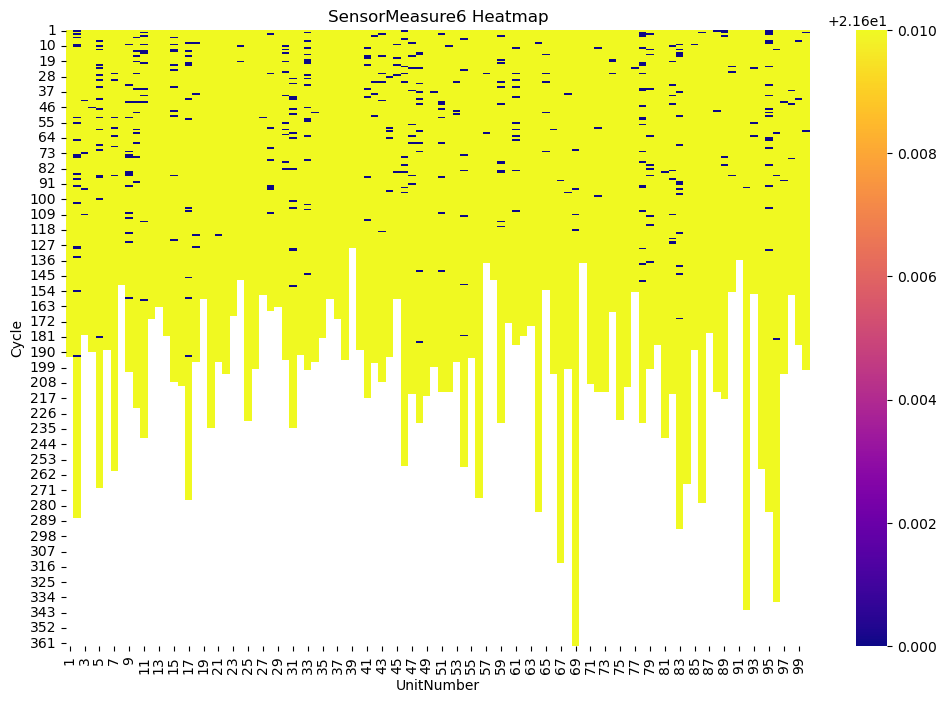

In [ ]:
s6= df_train.pivot(values='SensorMeasure6',columns='UnitNumber',index='Cycle')
plt.figure(figsize=(12,8))
sns.heatmap(s6, cmap='plasma')
plt.title("SensorMeasure6 Heatmap")
plt.ylabel("Cycle")
plt.xlabel("UnitNumber")
plt.show()

In [ ]:
df_train.SensorMeasure6.value_counts()

SensorMeasure6
21.61    20225
21.60      406
Name: count, dtype: int64

Sensor Measure 6 remains almost constant as well with some minor fluctuations and we can remove it as well.

In [ ]:
unnescary_feat= ["SensorMeasure1", "SensorMeasure5", "SensorMeasure6", "SensorMeasure10",
                      "SensorMeasure16", "SensorMeasure18", "SensorMeasure19"]
feats = []
for col in sensor_cols:
    if col not in unnescary_feat:
        feats.append(col)
feats

['SensorMeasure2',
 'SensorMeasure3',
 'SensorMeasure4',
 'SensorMeasure7',
 'SensorMeasure8',
 'SensorMeasure9',
 'SensorMeasure11',
 'SensorMeasure12',
 'SensorMeasure13',
 'SensorMeasure14',
 'SensorMeasure15',
 'SensorMeasure17',
 'SensorMeasure20',
 'SensorMeasure21']

In [ ]:
dropping_columns = ['SensorMeasure1','SensorMeasure5','SensorMeasure10',
             'SensorMeasure16','SensorMeasure18','SensorMeasure19','OpSet3']
df_cleaned= df_train.drop(columns=dropping_columns)

In [ ]:
df_cleaned.head()

,UnitNumber,Cycle,OpSet1,OpSet2,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure6,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


### Correlation Analysis

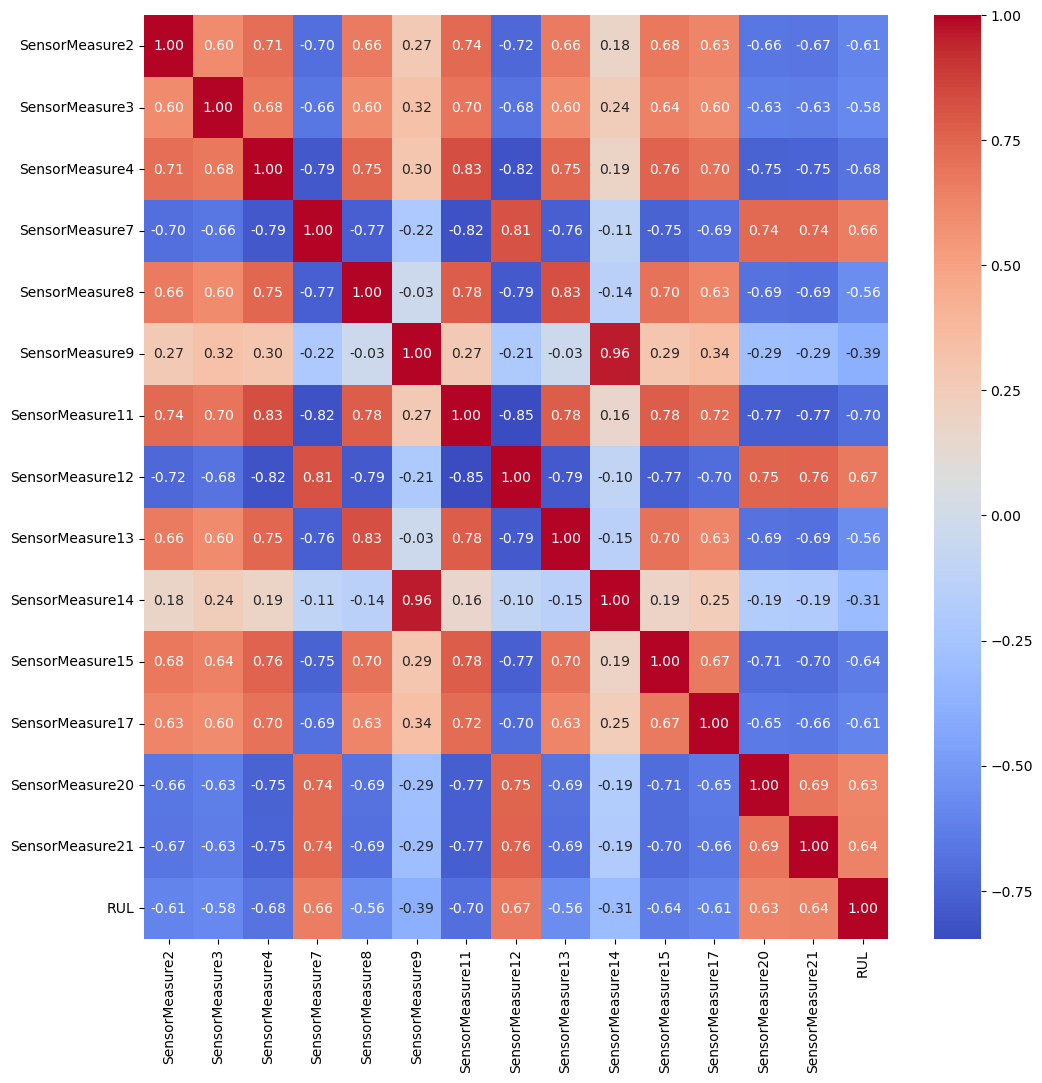

In [ ]:
corr = df_cleaned[feats + ["RUL"]].corr()

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111)
ax = sns.heatmap(corr, annot=True, cmap = "coolwarm", fmt=".2f")

As we can see, Sensor 14 and Sensor 9 are higly correlated.

<Axes: xlabel='SensorMeasure14', ylabel='SensorMeasure9'>

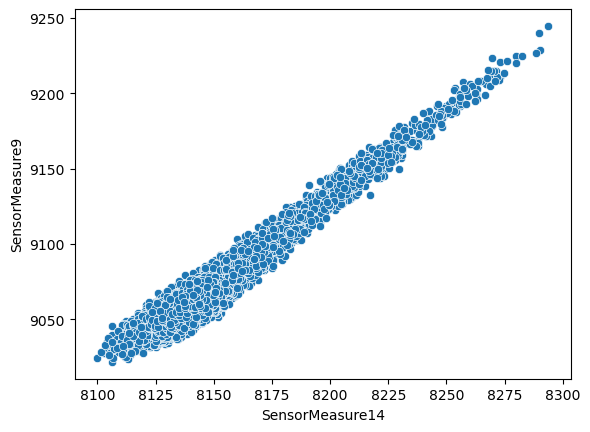

In [ ]:
sns.scatterplot(x =df_cleaned.SensorMeasure14, y = df_cleaned.SensorMeasure9)

Since both of these sensors are highly correlated with eachother and Sensor Measure 9 is higly correlated with RUL, we drop Sensor Measure 14.

### Visualizing sensor values before failure

In [ ]:
df_copy= df_train[df_train['UnitNumber'] <= 10]
df_copy1 = df_copy[df_copy['RUL'] <= 50]
df_copy2= df_copy1.reset_index(drop=True)
print(df_copy2.head())

   UnitNumber  Cycle  OpSet1  OpSet2  OpSet3  SensorMeasure1  SensorMeasure2  \
0           1    142  0.0026  0.0002   100.0          518.67          642.51   
1           1    143 -0.0005 -0.0003   100.0          518.67          642.77   
2           1    144  0.0025 -0.0004   100.0          518.67          643.09   
3           1    145 -0.0004 -0.0001   100.0          518.67          642.95   
4           1    146  0.0002 -0.0003   100.0          518.67          642.72   

   SensorMeasure3  SensorMeasure4  SensorMeasure5  ...  SensorMeasure13  \
0         1595.29         1413.42           14.62  ...          2388.18   
1         1593.10         1404.21           14.62  ...          2388.11   
2         1591.89         1405.76           14.62  ...          2388.17   
3         1594.92         1409.63           14.62  ...          2388.15   
4         1586.75         1408.82           14.62  ...          2388.12   

   SensorMeasure14  SensorMeasure15  SensorMeasure16  SensorMeasure1

In [ ]:
df_copy2.tail()

,UnitNumber,Cycle,OpSet1,OpSet2,OpSet3,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,...,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21,RUL
505,10,218,-0.0029,0.0004,100.0,518.67,643.70,1598.64,1426.21,14.62,...,2388.22,8173.14,8.4954,0.03,395,2388,100.0,38.47,23.1209,4
506,10,219,-0.0018,0.0004,100.0,518.67,643.46,1603.54,1424.54,14.62,...,2388.23,8177.31,8.5230,0.03,396,2388,100.0,38.48,23.2340,3
507,10,220,-0.0013,0.0002,100.0,518.67,643.46,1604.91,1422.76,14.62,...,2388.25,8181.11,8.5182,0.03,396,2388,100.0,38.53,23.2187,2
508,10,221,0.0005,-0.0001,100.0,518.67,644.09,1604.40,1432.13,14.62,...,2388.19,8183.38,8.5312,0.03,395,2388,100.0,38.22,23.1596,1
509,10,222,0.0002,-0.0003,100.0,518.67,643.66,1599.18,1436.29,14.62,...,2388.16,8183.55,8.5159,0.03,398,2388,100.0,38.51,23.1434,0


Visualizing different sensor values of last 50 cycles before failure

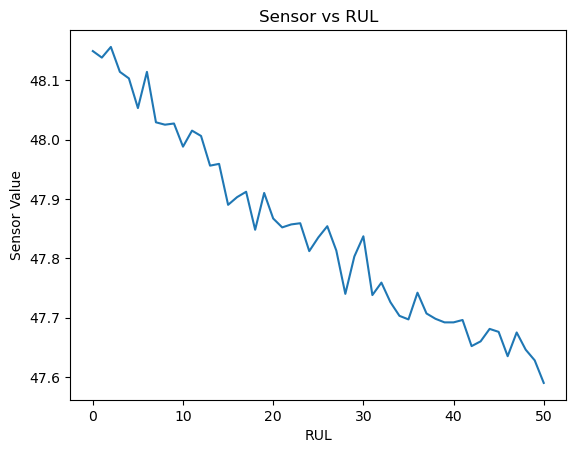

In [ ]:
s= 'SensorMeasure11'
avg_value= df_copy2.groupby('RUL')[s].mean()
plt.plot(avg_value)
plt.title("Sensor vs RUL")
plt.ylabel("Sensor Value")
plt.xlabel("RUL")
plt.show()

above graph show how the sensor value changes as the remaining life decreases.As RUL decreases, the sensor value change in this pattern, which helps us predict when engine will fail

In [ ]:
df_cleaned.head()


,UnitNumber,Cycle,OpSet1,OpSet2,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure6,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


['SensorMeasure1', 'SensorMeasure2', 'SensorMeasure3', 'SensorMeasure4', 'SensorMeasure5', 'SensorMeasure6', 'SensorMeasure7', 'SensorMeasure8', 'SensorMeasure9', 'SensorMeasure10', 'SensorMeasure11', 'SensorMeasure12', 'SensorMeasure13', 'SensorMeasure14', 'SensorMeasure15', 'SensorMeasure16', 'SensorMeasure17', 'SensorMeasure18', 'SensorMeasure19', 'SensorMeasure20', 'SensorMeasure21']


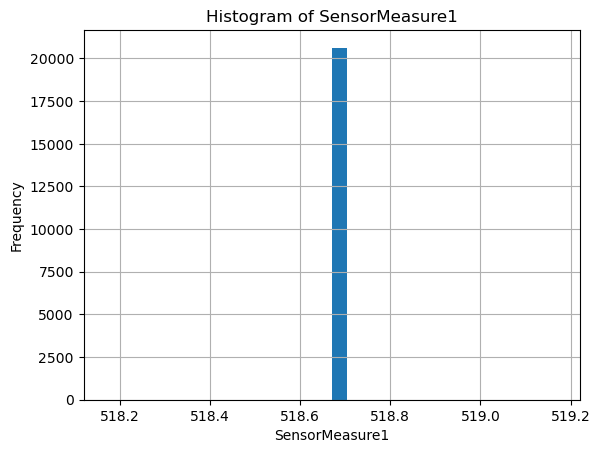

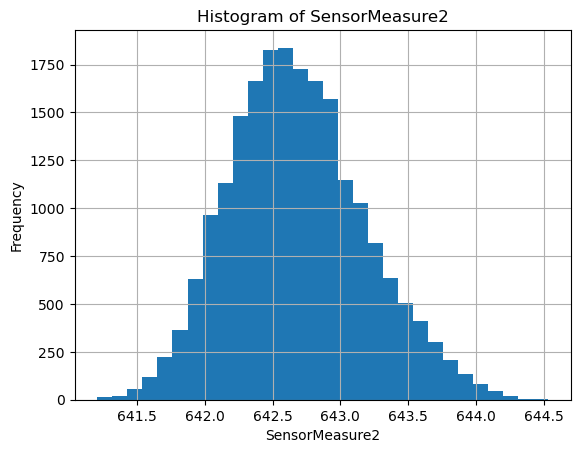

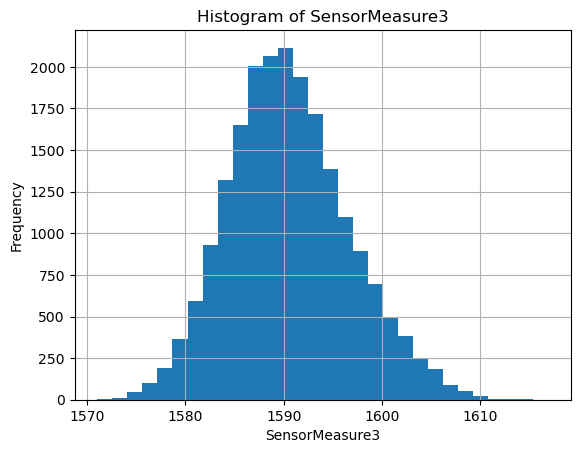

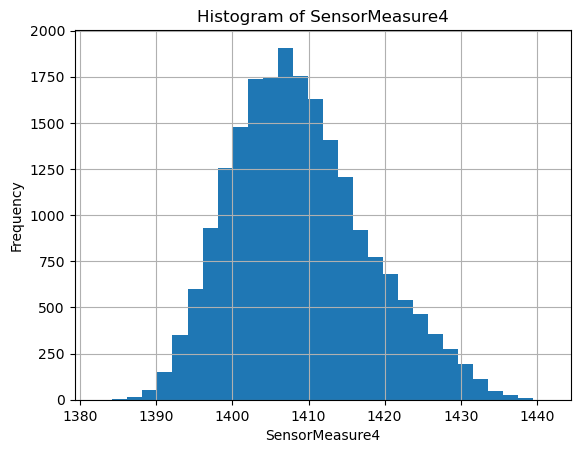

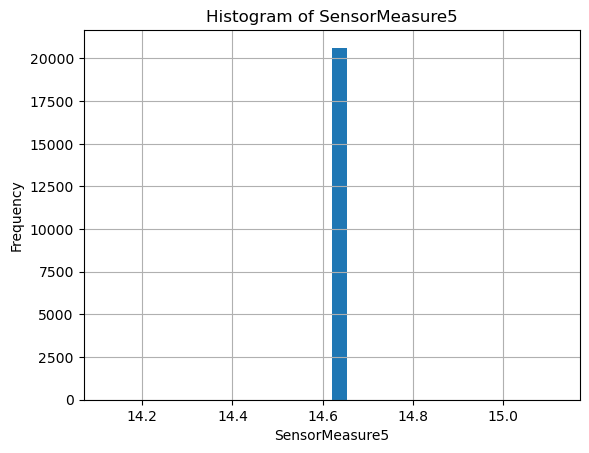

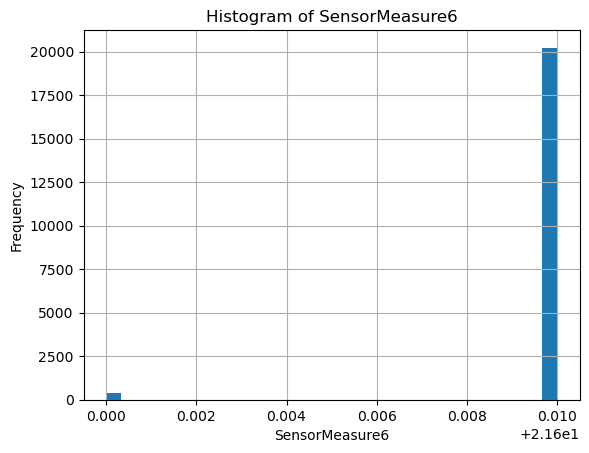

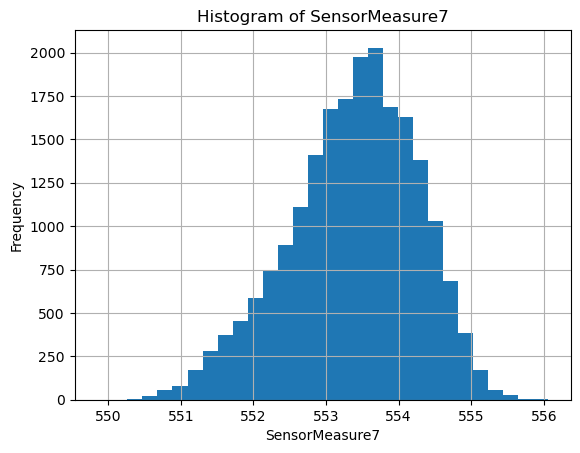

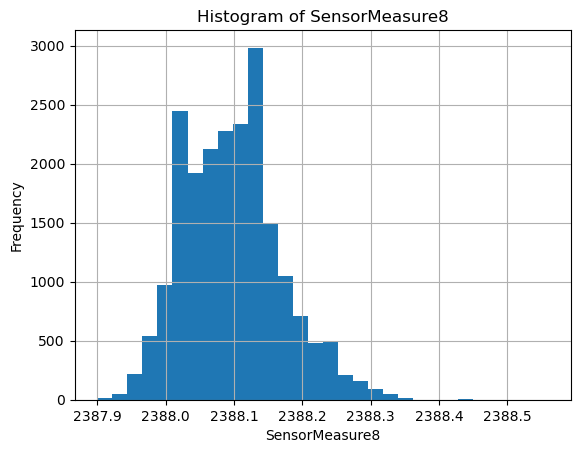

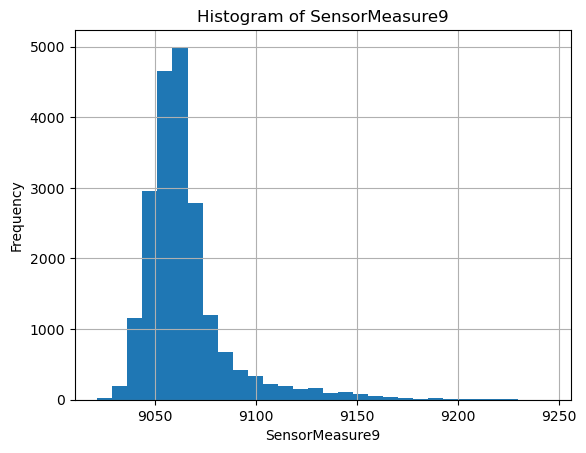

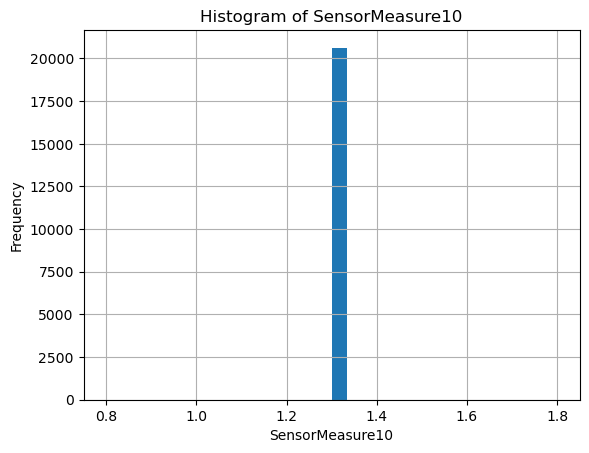

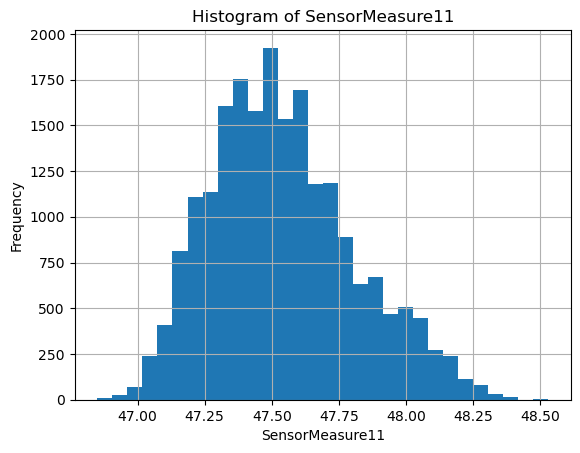

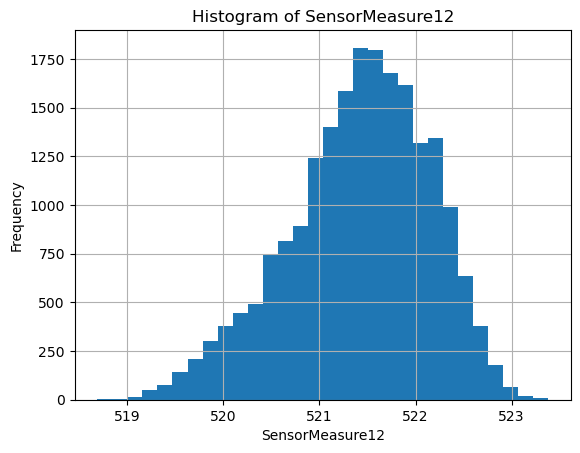

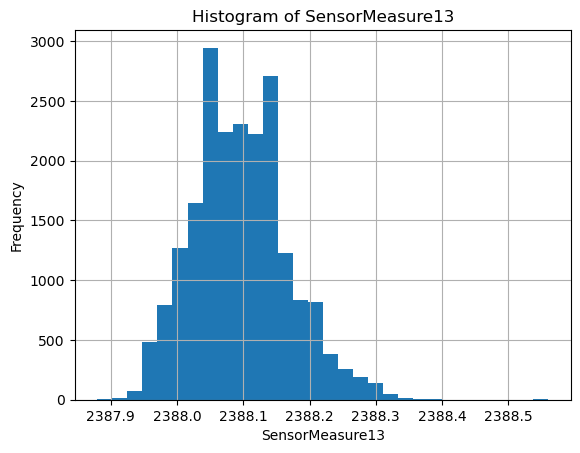

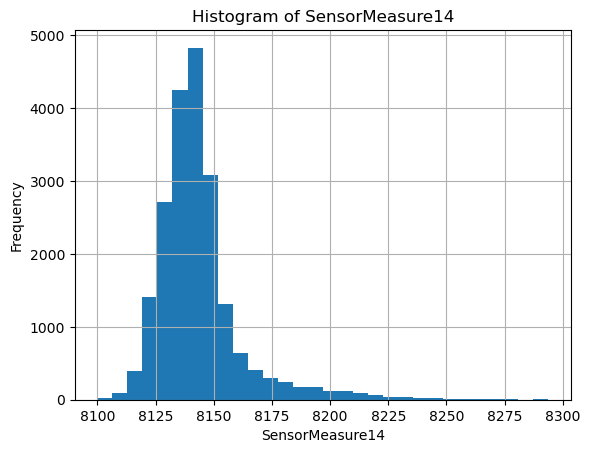

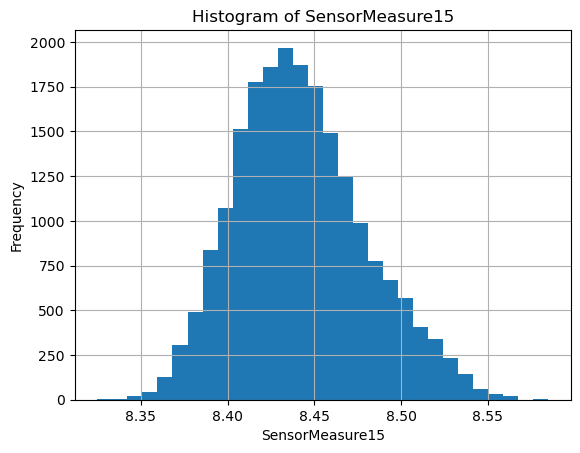

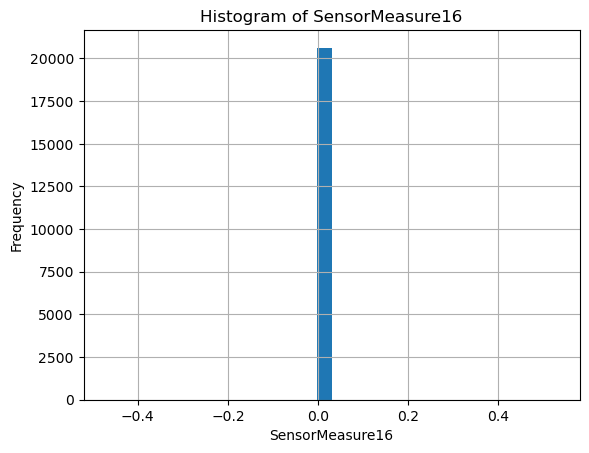

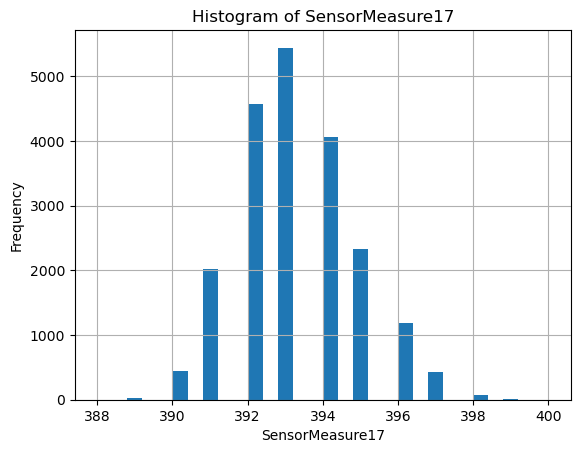

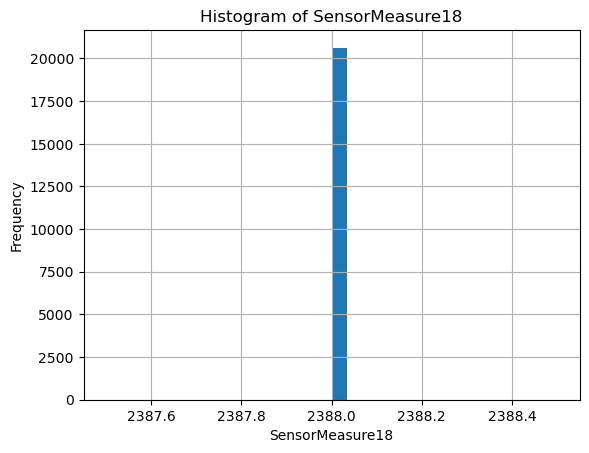

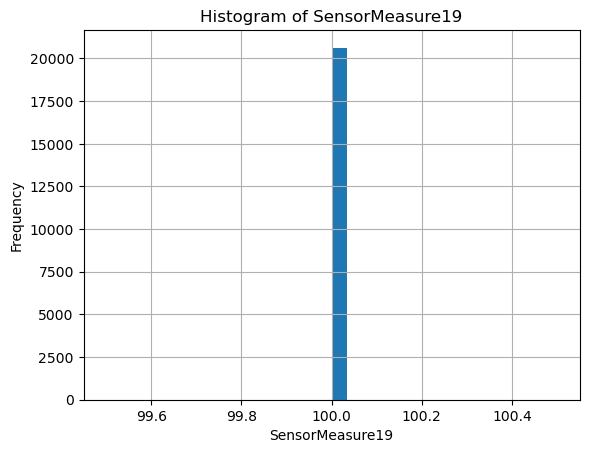

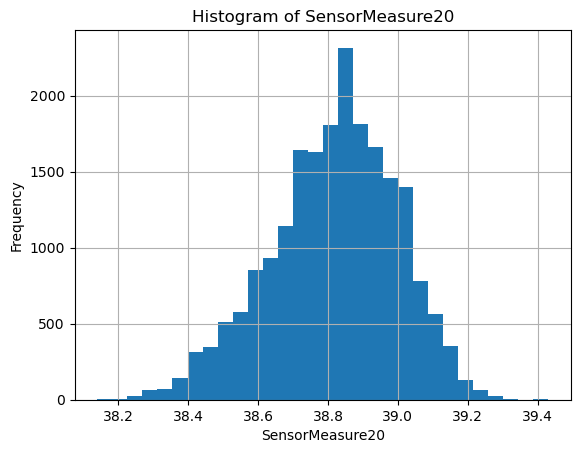

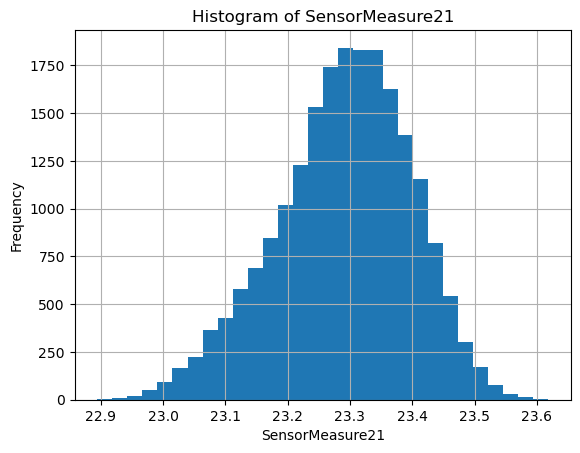

In [ ]:
sensor_list = []

for col in df_train.columns:
    if "SensorMeasure" in col:
        sensor_list.append(col)

print(sensor_list)

for sensor in sensor_list:
    plt.figure()
    plt.hist(df_train[sensor], bins=30)
    plt.title(f"Histogram of {sensor}")
    plt.xlabel(sensor)
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

In [ ]:
range_df = pd.DataFrame({
    "Min": df_train[sensor_list].min(),
    "Max": df_train[sensor_list].max(),
    "Mean": df_train[sensor_list].mean()
})

print(range_df)

                       Min        Max         Mean
SensorMeasure1    518.6700   518.6700   518.670000
SensorMeasure2    641.2100   644.5300   642.680934
SensorMeasure3   1571.0400  1616.9100  1590.523119
SensorMeasure4   1382.2500  1441.4900  1408.933782
SensorMeasure5     14.6200    14.6200    14.620000
SensorMeasure6     21.6000    21.6100    21.609803
SensorMeasure7    549.8500   556.0600   553.367711
SensorMeasure8   2387.9000  2388.5600  2388.096652
SensorMeasure9   9021.7300  9244.5900  9065.242941
SensorMeasure10     1.3000     1.3000     1.300000
SensorMeasure11    46.8500    48.5300    47.541168
SensorMeasure12   518.6900   523.3800   521.413470
SensorMeasure13  2387.8800  2388.5600  2388.096152
SensorMeasure14  8099.9400  8293.7200  8143.752722
SensorMeasure15     8.3249     8.5848     8.442146
SensorMeasure16     0.0300     0.0300     0.030000
SensorMeasure17   388.0000   400.0000   393.210654
SensorMeasure18  2388.0000  2388.0000  2388.000000
SensorMeasure19   100.0000   10

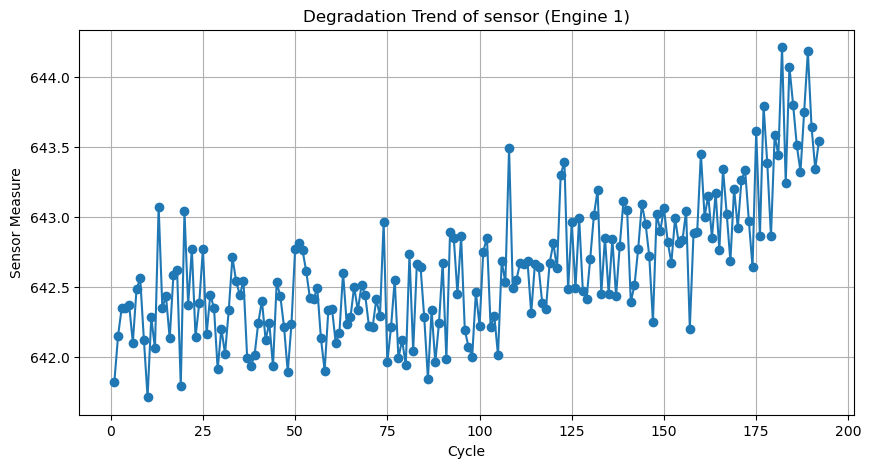

In [ ]:
engine_id = df_train['UnitNumber'].iloc[0]
engine_data = df_train[df_train['UnitNumber'] == engine_id]

# Choose a sensor (example: Sensor2 or change as needed)
sensor = 'SensorMeasure2'

# Plot degradation trend
plt.figure(figsize=(10, 5))
plt.plot(engine_data['Cycle'], engine_data[sensor], marker='o')

plt.title(f"Degradation Trend of sensor (Engine {engine_id})")
plt.xlabel("Cycle")
plt.ylabel("Sensor Measure")

plt.grid()
plt.show()

In [ ]:
df_cleaned.to_csv("train_cleaned_data.csv", index=False)-